# US Superstore Analysis

## 1. Data Preparation

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact, Dropdown
import warnings

warnings.filterwarnings('ignore')

df = pd.read_excel('data/US Superstore data.xls')

print('Shape:', df.shape)
print(df.columns.tolist())
df.head()


Shape: (9994, 21)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.info()
df.describe(include='all')
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [9]:
# Remove duplicates
df = df.drop_duplicates()

print('Dataset shape before cleaning:', df.shape)

# Example missing values handling (use DataFrame.ffill to avoid the fillna 'method' argument issue)
df_cleaned= df.ffill()

print('Dataset shape after cleaning:', df_cleaned.shape)


Dataset shape before cleaning: (9994, 21)
Dataset shape after cleaning: (9994, 21)


## 2. Data Visualization with Matplotlib

In [10]:
# Convert Order Date if present
if 'Order Date' in df.columns:
    df['Order Date'] = pd.to_datetime(df['Order Date'])
    df['Year'] = df['Order Date'].dt.year


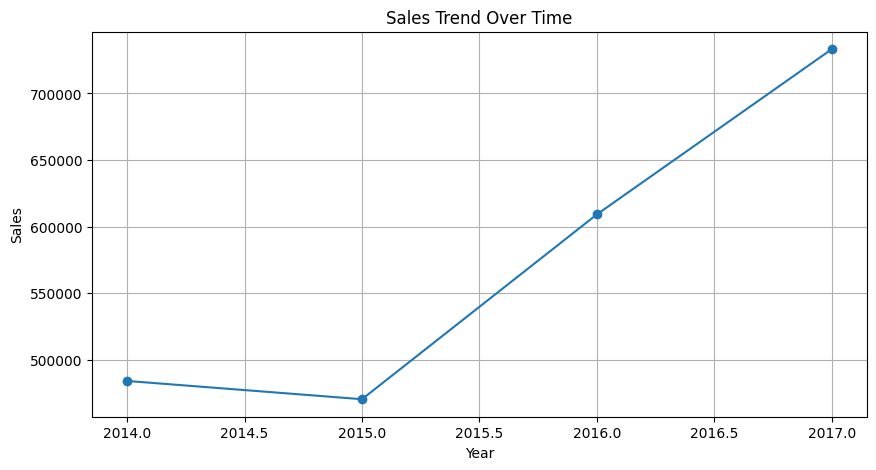

In [11]:
# Interactive sales trend

def sales_trend():
    yearly_sales = df.groupby('Year')['Sales'].sum()

    plt.figure(figsize=(10,5))
    plt.plot(yearly_sales.index, yearly_sales.values, marker='o')
    plt.title('Sales Trend Over Time')
    plt.xlabel('Year')
    plt.ylabel('Sales')
    plt.grid(True)
    plt.show()

sales_trend()


In [13]:
# Interactive Country Sales Distribution

country_column = 'Country' if 'Country' in df.columns else None

if country_column:

    sales_by_country = df.groupby(country_column)['Sales'].sum().sort_values()

    def show_countries(top_n=10):
        plt.figure(figsize=(10,6))
        sales_by_country.tail(top_n).plot(kind='barh')
        plt.title('Sales Distribution by Country')
        plt.show()

    # Guard against invalid widget bounds when there are few (or one) countries
    max_n = max(1, len(sales_by_country))
    default_n = min(10, max_n)
    interact(show_countries, top_n=widgets.IntSlider(min=1, max=max_n, step=1, value=default_n))


interactive(children=(IntSlider(value=1, description='top_n', max=1, min=1), Output()), _dom_classes=('widget-…

## 3. Data Visualization with Seaborn

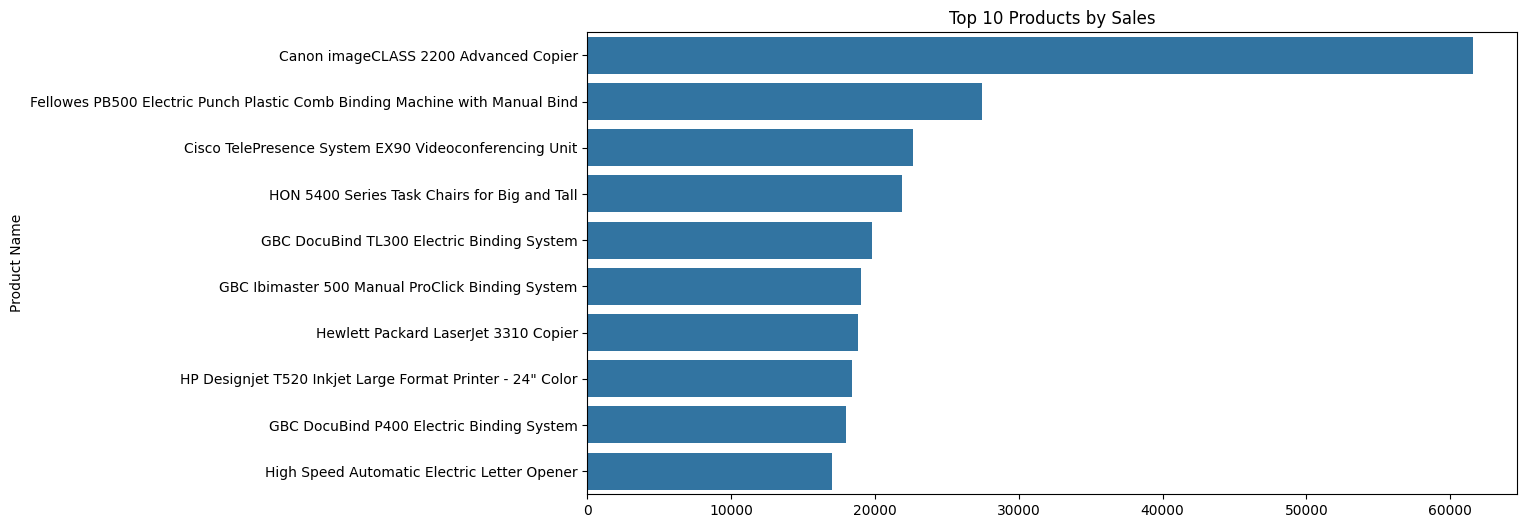

In [14]:
top_products = (
    df.groupby('Product Name')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))
sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title('Top 10 Products by Sales')
plt.show()


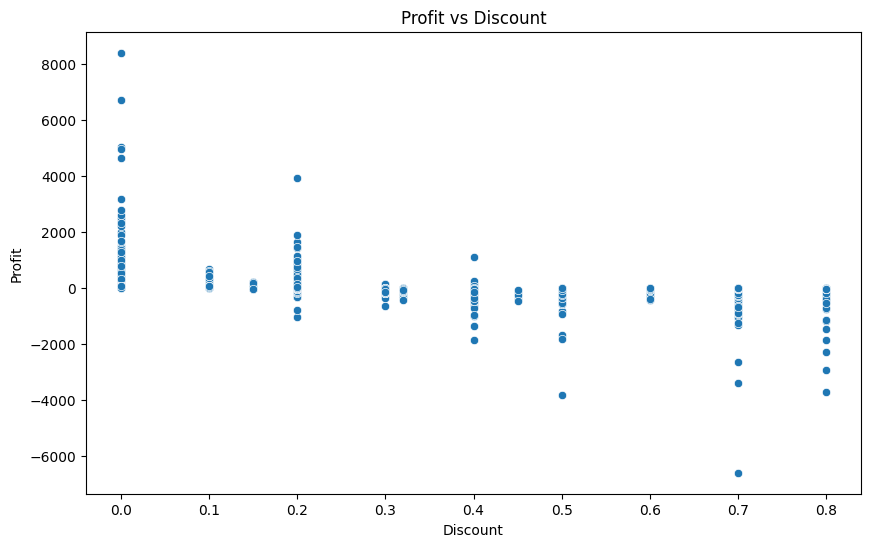

In [15]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit'
)

plt.title('Profit vs Discount')
plt.show()


## 4. Comparative Analysis

### Matplotlib
- Flexible and highly customizable.
- Useful for interactive business charts.

### Seaborn
- Easier statistical visualization.
- Better default aesthetics.

### Observations
- Matplotlib was useful for trend exploration.
- Seaborn made relationship analysis easier.
- Both tools complement each other in business intelligence projects.


## 5. Insights

### Key Findings
- Identify the years with the highest sales.
- Determine the countries generating the most revenue.
- Identify top-performing products.
- Analyze whether larger discounts reduce profitability.

### Recommendation
- Focus on high-performing products and regions.
- Review discount strategies when profit becomes negative.
